# 01. Exploratory Data Analysis — Online Retail II

**목표:** 데이터 구조 파악 → 결측치/이상치 처리 → 매출 패턴 탐색  
**다음 단계:** `02_feature_engineering.ipynb` (RFM 피처 생성)

## 0. Setup

In [2]:
import sys
sys.path.append("../../")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from shared.plot_config import set_style
set_style()

DATA_PATH = "../data/raw/online_retail_II.xlsx"
PROCESSED_PATH = "../data/processed/retail_clean.parquet"

## 1. 데이터 로딩

In [3]:
# 엑셀 파일에 시트가 2개(Year 2009-2010, Year 2010-2011) 있으므로 합쳐서 로드
df_09 = pd.read_excel(DATA_PATH, sheet_name="Year 2009-2010")
df_10 = pd.read_excel(DATA_PATH, sheet_name="Year 2010-2011")
df_raw = pd.concat([df_09, df_10], ignore_index=True)

print(f"Shape: {df_raw.shape}")
df_raw.head()

Shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 78.8+ MB


## 2. 결측치 분석

In [5]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
pd.DataFrame({"missing": missing, "pct(%)": missing_pct}).query("missing > 0").sort_values("pct(%)", ascending=False)

,missing,pct(%)
Customer ID,243007,22.77
Description,4382,0.41


## 3. 데이터 클리닝

In [6]:
df = df_raw.copy()

# 1) CustomerID 없는 행 제거 (RFM 분석 불가)
df = df.dropna(subset=["Customer ID"])

# 2) 취소 주문 제거 (Invoice가 'C'로 시작)
df = df[~df["Invoice"].astype(str).str.startswith("C")]

# 3) Quantity, Price 음수/0 제거
df = df[(df["Quantity"] > 0) & (df["Price"] > 0)]

# 4) 파생 컬럼: 총 매출액
df["Revenue"] = df["Quantity"] * df["Price"]

# 5) 타입 정리
df["Customer ID"] = df["Customer ID"].astype(int)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print(f"클리닝 전: {df_raw.shape[0]:,}행 → 클리닝 후: {df.shape[0]:,}행")
df.head()

클리닝 전: 1,067,371행 → 클리닝 후: 805,549행


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


## 4. 기본 통계

In [7]:
print("=== 기간 ===")
print(f"  시작: {df['InvoiceDate'].min().date()}")
print(f"  종료: {df['InvoiceDate'].max().date()}")
print()
print("=== 규모 ===")
print(f"  총 거래 건수:  {df['Invoice'].nunique():,}")
print(f"  총 고객 수:    {df['Customer ID'].nunique():,}")
print(f"  총 상품 종류:  {df['StockCode'].nunique():,}")
print(f"  총 국가 수:    {df['Country'].nunique():,}")
print()
print("=== 매출 ===")
print(f"  총 매출:       £{df['Revenue'].sum():,.0f}")
print(f"  주문당 평균:   £{df.groupby('Invoice')['Revenue'].sum().mean():,.2f}")
print(f"  고객당 평균:   £{df.groupby('Customer ID')['Revenue'].sum().mean():,.2f}")

=== 기간 ===
  시작: 2009-12-01
  종료: 2011-12-09

=== 규모 ===
  총 거래 건수:  36,969
  총 고객 수:    5,878
  총 상품 종류:  4,631
  총 국가 수:    41

=== 매출 ===
  총 매출:       £17,743,429
  주문당 평균:   £479.95
  고객당 평균:   £3,018.62


## 5. 시각화

### 5-1. 월별 매출 트렌드

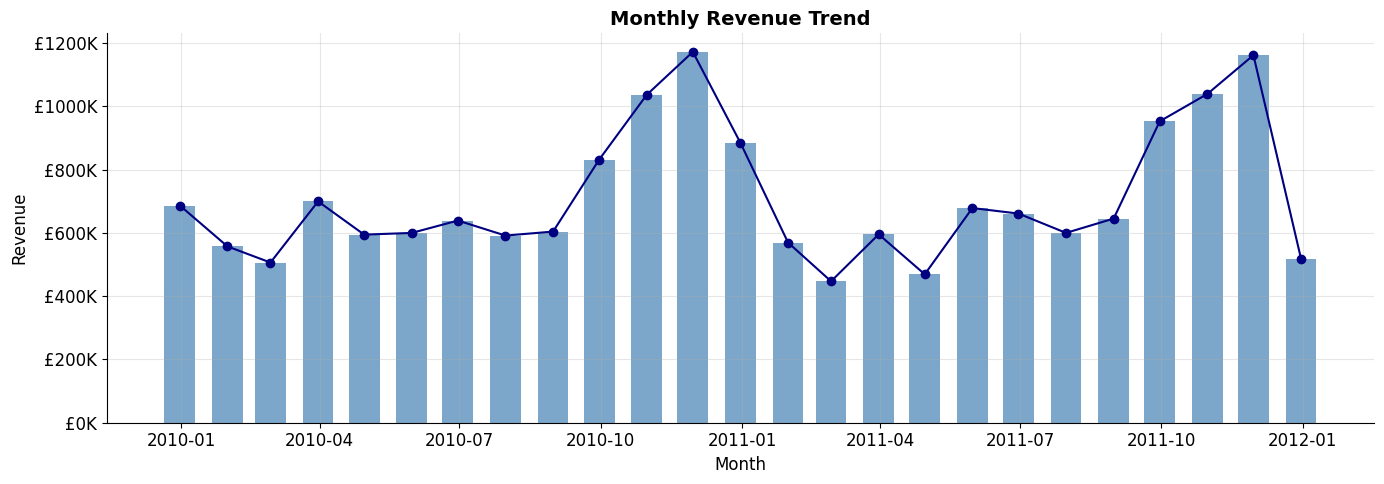

In [8]:
monthly = (
    df.set_index("InvoiceDate")
    .resample("ME")["Revenue"]
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(monthly["InvoiceDate"], monthly["Revenue"], width=20, alpha=0.7, color="steelblue")
ax.plot(monthly["InvoiceDate"], monthly["Revenue"], marker="o", color="navy", linewidth=1.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x/1000:.0f}K"))
ax.set_title("Monthly Revenue Trend", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue")
plt.tight_layout()
plt.savefig("../outputs/figures/monthly_revenue.png", dpi=150, bbox_inches="tight")
plt.show()

### 5-2. 요일별 / 시간대별 주문 패턴

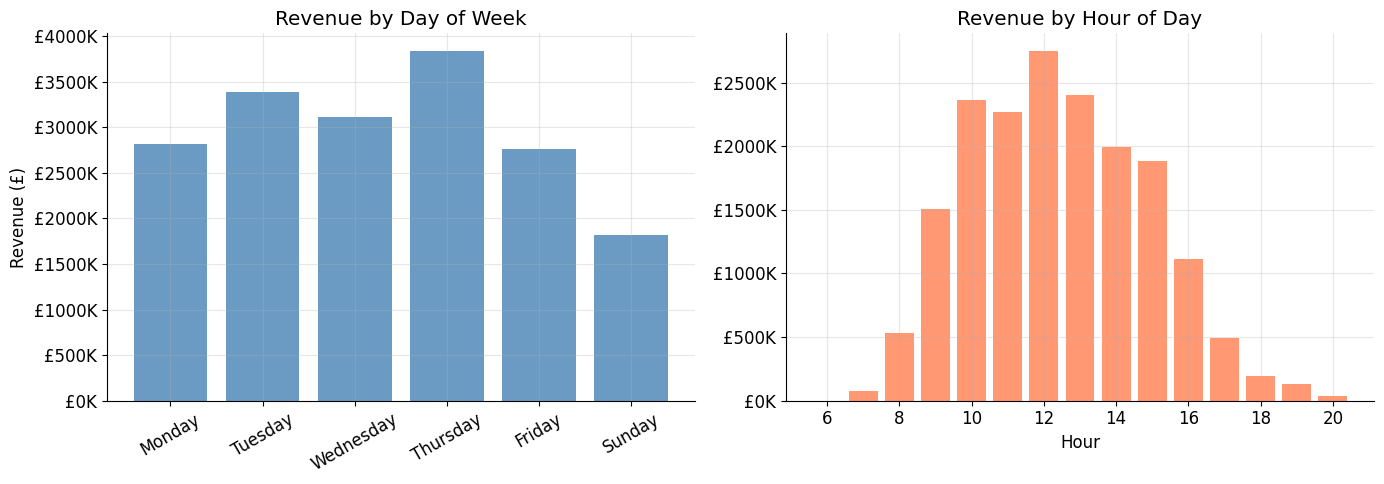

In [9]:
df["DayOfWeek"] = df["InvoiceDate"].dt.day_name()
df["Hour"] = df["InvoiceDate"].dt.hour

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Sunday"]
day_revenue = df.groupby("DayOfWeek")["Revenue"].sum().reindex(day_order)
hour_revenue = df.groupby("Hour")["Revenue"].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(day_revenue.index, day_revenue.values, color="steelblue", alpha=0.8)
axes[0].set_title("Revenue by Day of Week")
axes[0].set_ylabel("Revenue (£)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x/1000:.0f}K"))
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(hour_revenue.index, hour_revenue.values, color="coral", alpha=0.8)
axes[1].set_title("Revenue by Hour of Day")
axes[1].set_xlabel("Hour")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x/1000:.0f}K"))

plt.tight_layout()
plt.savefig("../outputs/figures/time_pattern.png", dpi=150, bbox_inches="tight")
plt.show()

### 5-3. 국가별 매출 (Top 10)

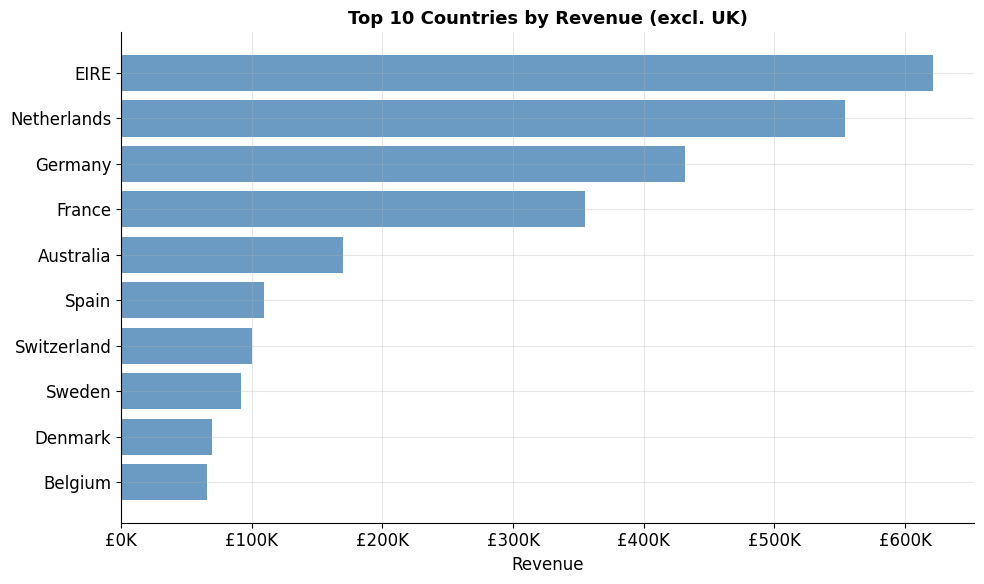

In [10]:
country_rev = (
    df[df["Country"] != "United Kingdom"]  # UK 제외 (압도적 비율)
    .groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=True)
    .tail(10)
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(country_rev.index, country_rev.values, color="steelblue", alpha=0.8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x/1000:.0f}K"))
ax.set_title("Top 10 Countries by Revenue (excl. UK)", fontsize=13, fontweight="bold")
ax.set_xlabel("Revenue")
plt.tight_layout()
plt.savefig("../outputs/figures/country_revenue.png", dpi=150, bbox_inches="tight")
plt.show()

### 5-4. 고객 매출 분포 (상위 집중도)

상위 10% 고객이 전체 매출의 63.9% 차지
상위 20% 고객이 전체 매출의 77.2% 차지


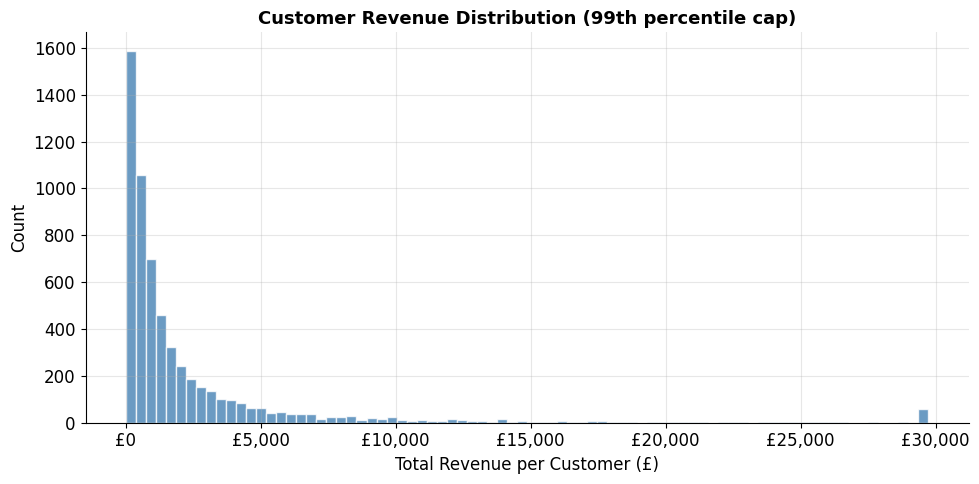

In [11]:
customer_rev = df.groupby("Customer ID")["Revenue"].sum().sort_values(ascending=False)
top10_pct = customer_rev.head(int(len(customer_rev) * 0.1)).sum() / customer_rev.sum() * 100
top20_pct = customer_rev.head(int(len(customer_rev) * 0.2)).sum() / customer_rev.sum() * 100

print(f"상위 10% 고객이 전체 매출의 {top10_pct:.1f}% 차지")
print(f"상위 20% 고객이 전체 매출의 {top20_pct:.1f}% 차지")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(customer_rev.clip(upper=customer_rev.quantile(0.99)), bins=80, color="steelblue", alpha=0.8, edgecolor="white")
ax.set_title("Customer Revenue Distribution (99th percentile cap)", fontsize=13, fontweight="bold")
ax.set_xlabel("Total Revenue per Customer (£)")
ax.set_ylabel("Count")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
plt.tight_layout()
plt.savefig("../outputs/figures/customer_revenue_dist.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. 클린 데이터 저장

In [12]:
# 다음 노트북에서 바로 사용할 수 있도록 parquet으로 저장
df.to_parquet(PROCESSED_PATH, index=False)
print(f"Saved → {PROCESSED_PATH}")
print(f"Shape: {df.shape}")

ArrowInvalid: ("Could not convert '79323P' with type str: tried to convert to int64", 'Conversion failed for column StockCode with type object')